# Lab 4 – Assessment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure
from skimage.exposure import match_histograms

## Task 1

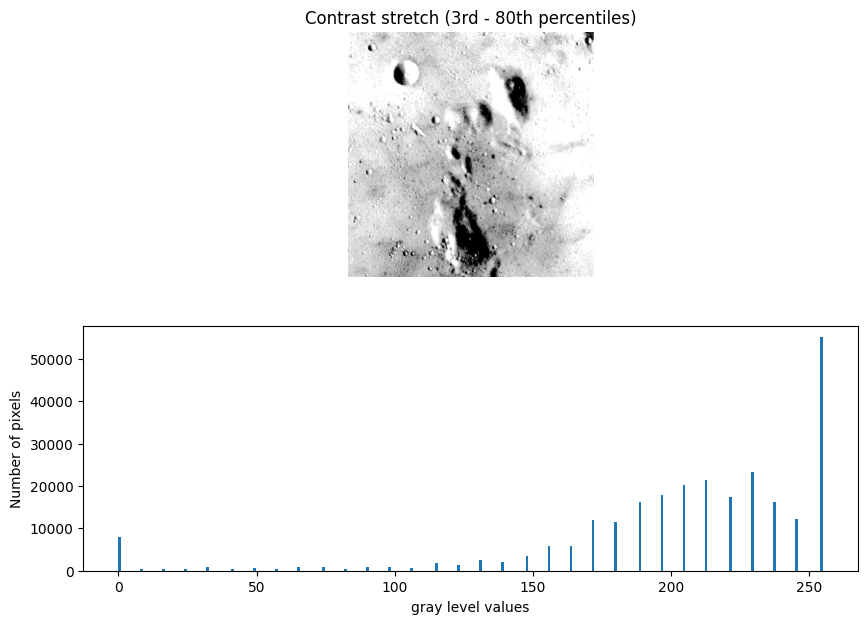

In [2]:
img = data.moon()
p3, p80 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd - 80th percentiles)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

## Task 2

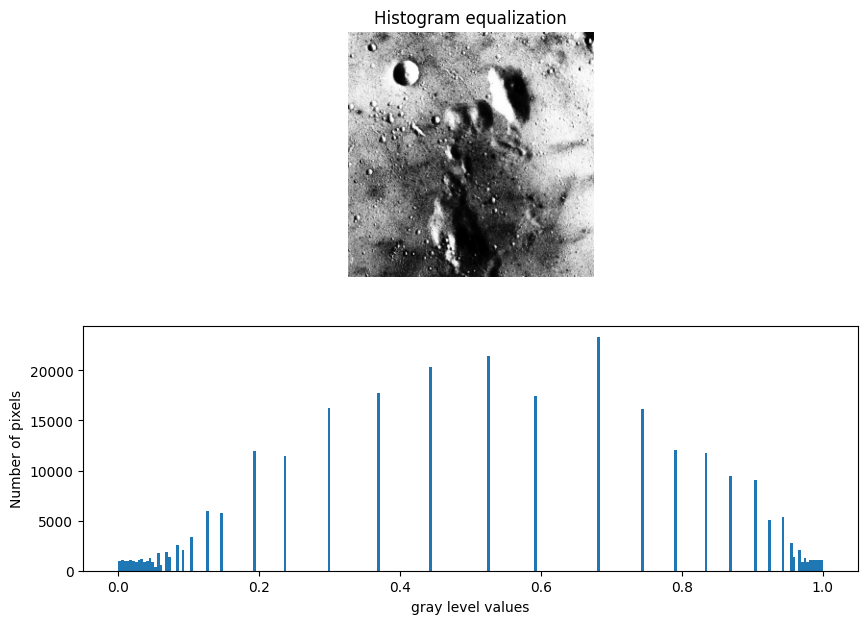

In [3]:
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

## Task 3

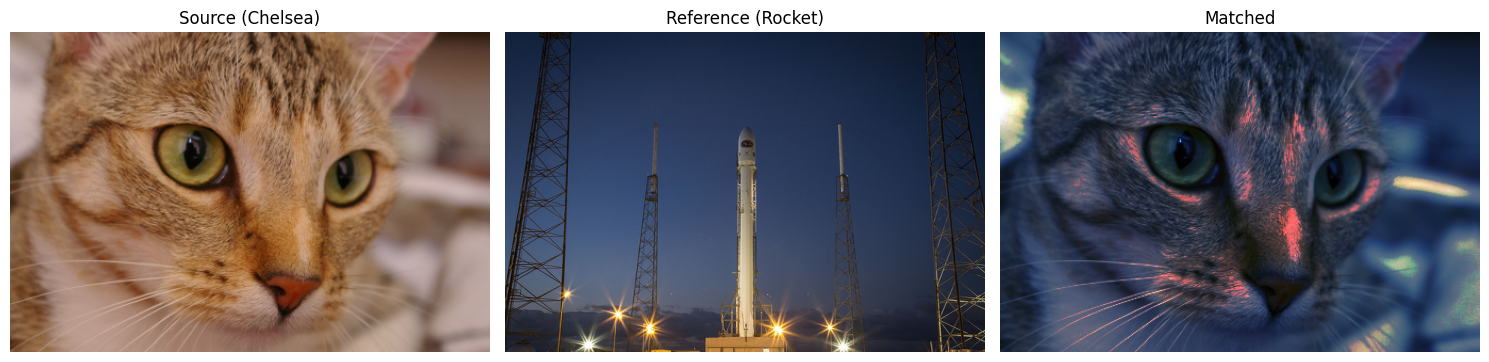

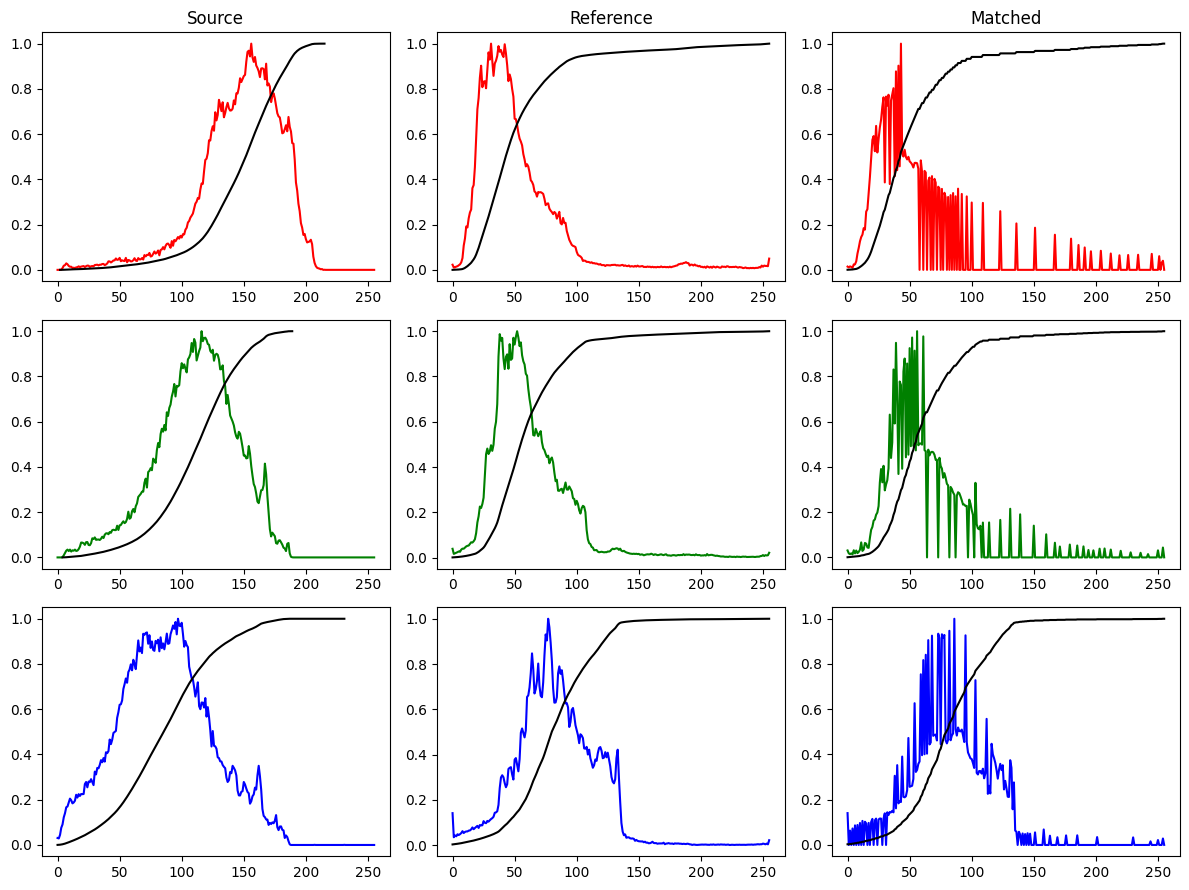

In [4]:
reference = data.rocket()
image = data.chelsea()
matched = match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, title in zip(axes, [image, reference, matched], ['Source (Chelsea)', 'Reference (Rocket)', 'Matched']):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, im in enumerate([image, reference, matched]):
    for c, color in enumerate(['red', 'green', 'blue']):
        hist, bins = exposure.histogram(im[..., c], source_range='dtype')
        axes[c, i].plot(bins, hist / hist.max(), color=color)
        img_cdf, bins = exposure.cumulative_distribution(im[..., c])
        axes[c, i].plot(bins, img_cdf, 'k')
    axes[0, i].set_title(['Source', 'Reference', 'Matched'][i])
plt.tight_layout()
plt.show()